# Customer Churn — Exploratory Data Analysis

This notebook walks through the Telco Customer Churn dataset to understand
which factors drive churn. The goal isn't to be exhaustive — it's to find
the patterns that will actually matter for building the model.

Dataset: IBM Watson Analytics Telco Customer Churn  
Rows: 7,043 customers | Columns: 21


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# consistent style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/raw.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Dataset Overview

In [2]:
print('Column types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Column types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing values:
TotalCharges    11
dtype: int64


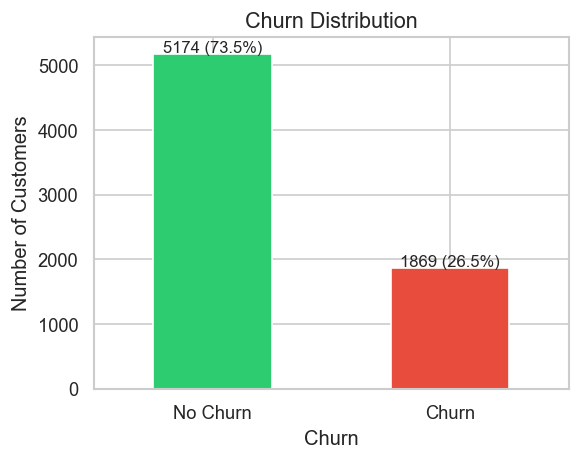


Churn rate: 26.5%
→ Moderate imbalance. Will use class_weight="balanced" in models.


In [3]:
# Churn distribution — class imbalance check
churn_counts = df['Churn'].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
churn_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'], ax=ax, width=0.5)
ax.set_title('Churn Distribution', fontsize=13)
ax.set_ylabel('Number of Customers')
ax.set_xticklabels(['No Churn', 'Churn'], rotation=0)
for i, v in enumerate(churn_counts):
    ax.text(i, v + 30, f'{v} ({v/len(df):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print(f'\nChurn rate: {df["Churn"].eq("Yes").mean():.1%}')
print('→ Moderate imbalance. Will use class_weight="balanced" in models.')

## 2. Churn vs Tenure

Tenure = how many months the customer has been with the company.

**Hypothesis:** New customers churn more. They haven't built up switching costs
and may have joined on a promo deal that expired.

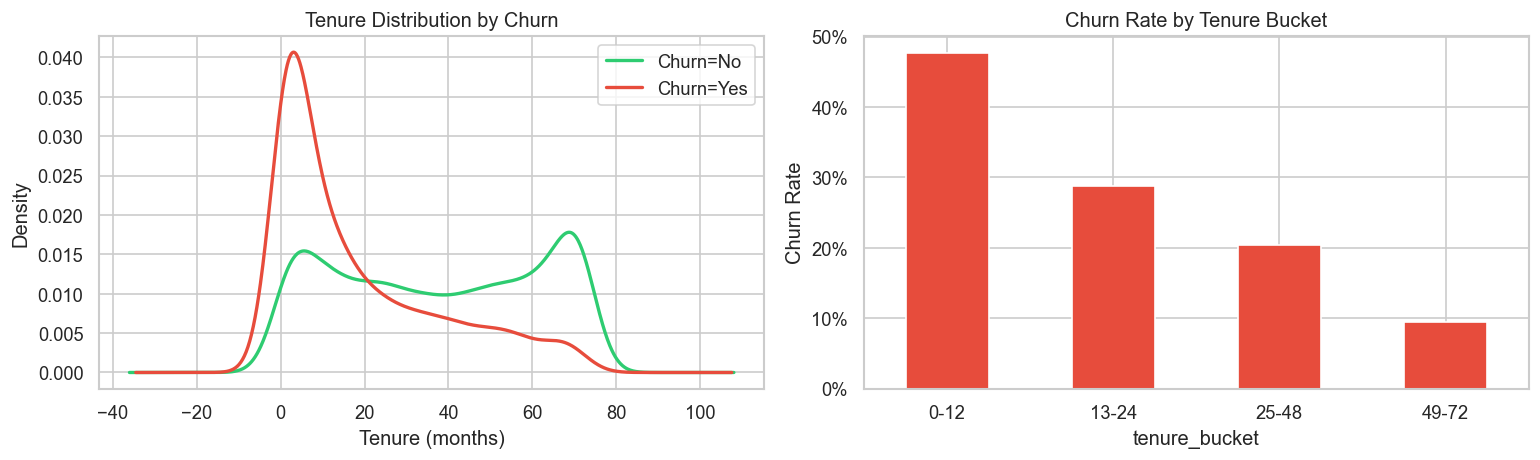


Insight: Customers in their first year (0-12 months) have a ~47% churn rate.
This drops sharply as tenure increases — loyalty grows over time.
Tenure is almost certainly going to be one of the top predictors.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# KDE plot
for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
    subset = df[df['Churn'] == label]['tenure']
    subset.plot.kde(ax=axes[0], label=f'Churn={label}', color=color, lw=2)
axes[0].set_title('Tenure Distribution by Churn', fontsize=12)
axes[0].set_xlabel('Tenure (months)')
axes[0].legend()

# Churn rate by tenure bucket
df['tenure_bucket'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], labels=['0-12','13-24','25-48','49-72'])
churn_by_tenure = df.groupby('tenure_bucket', observed=True)['Churn'].apply(lambda x: (x=='Yes').mean())
churn_by_tenure.plot(kind='bar', ax=axes[1], color='#e74c3c', width=0.5)
axes[1].set_title('Churn Rate by Tenure Bucket', fontsize=12)
axes[1].set_ylabel('Churn Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

print('\nInsight: Customers in their first year (0-12 months) have a ~47% churn rate.')
print('This drops sharply as tenure increases — loyalty grows over time.')
print('Tenure is almost certainly going to be one of the top predictors.')

## 3. Churn vs Monthly Charges

**Hypothesis:** Higher monthly charges → higher churn. 
Customers on expensive plans may feel they're not getting value.

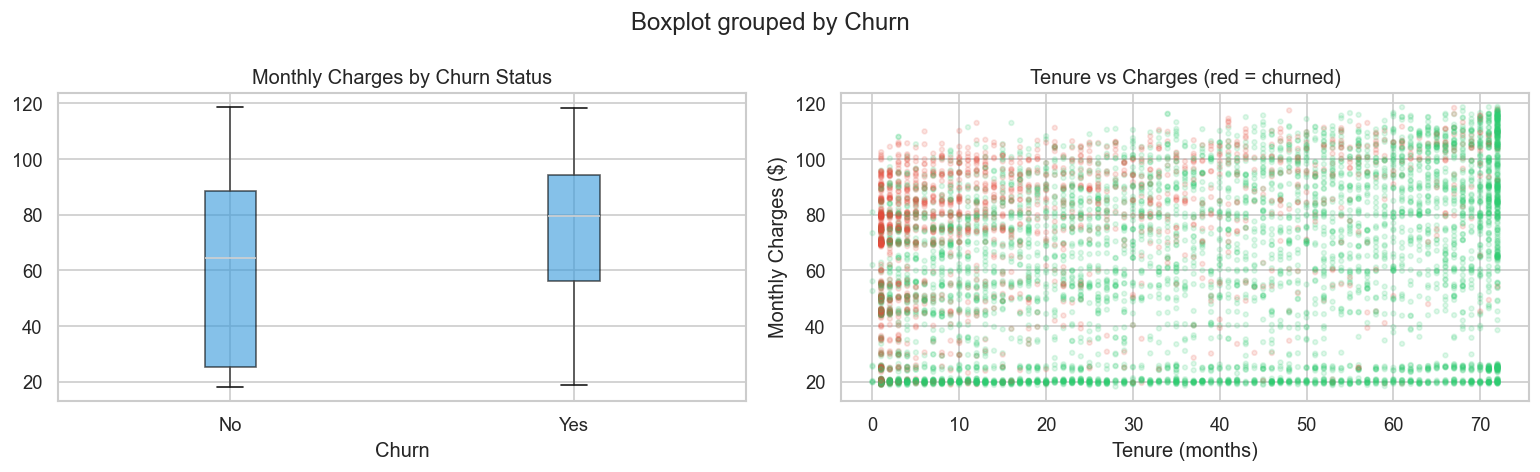

Median monthly charge — Churned: $79.65 | Not Churned: $64.43

Insight: Churned customers pay ~$20/month more on average.
The top-left quadrant (new + expensive) is the highest risk zone.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Box plot
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[0],
           patch_artist=True, boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[0].set_title('Monthly Charges by Churn Status')
axes[0].set_xlabel('Churn')
plt.sca(axes[0])
plt.title('Monthly Charges by Churn Status')

# Scatter: tenure vs monthly charges, colored by churn
colors = df['Churn'].map({'No': '#2ecc71', 'Yes': '#e74c3c'})
axes[1].scatter(df['tenure'], df['MonthlyCharges'], c=colors, alpha=0.15, s=8)
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Monthly Charges ($)')
axes[1].set_title('Tenure vs Charges (red = churned)')

plt.tight_layout()
plt.show()

churn_yes_median = df[df['Churn']=='Yes']['MonthlyCharges'].median()
churn_no_median = df[df['Churn']=='No']['MonthlyCharges'].median()
print(f'Median monthly charge — Churned: ${churn_yes_median:.2f} | Not Churned: ${churn_no_median:.2f}')
print('\nInsight: Churned customers pay ~$20/month more on average.')
print('The top-left quadrant (new + expensive) is the highest risk zone.')

## 4. Churn by Contract Type

This one should be obvious but it's worth confirming in the data.

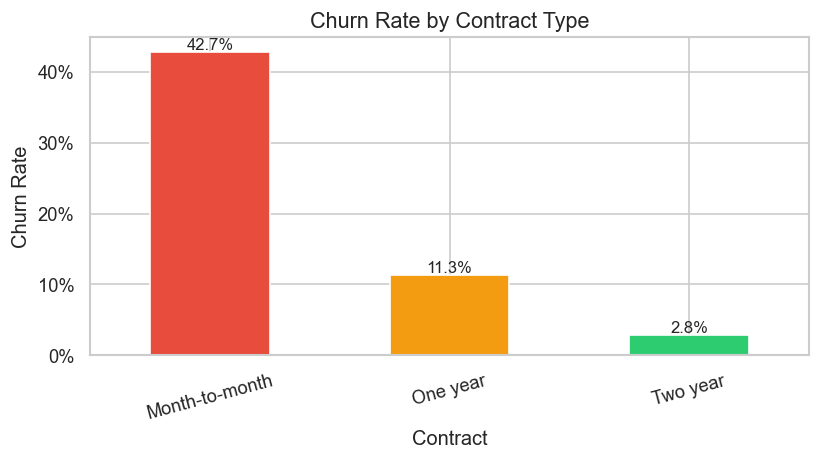

Insight: Month-to-month customers churn at 43% vs 3% for two-year contracts.
Contract type is probably the strongest single predictor of churn.
Business implication: push customers toward longer contracts early.


In [6]:
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
contract_churn.plot(kind='bar', ax=ax, color=['#e74c3c','#f39c12','#2ecc71'], width=0.5)
ax.set_title('Churn Rate by Contract Type', fontsize=13)
ax.set_ylabel('Churn Rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for i, v in enumerate(contract_churn):
    ax.text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print('Insight: Month-to-month customers churn at 43% vs 3% for two-year contracts.')
print('Contract type is probably the strongest single predictor of churn.')
print('Business implication: push customers toward longer contracts early.')

## 5. Churn by Internet Service & Add-ons

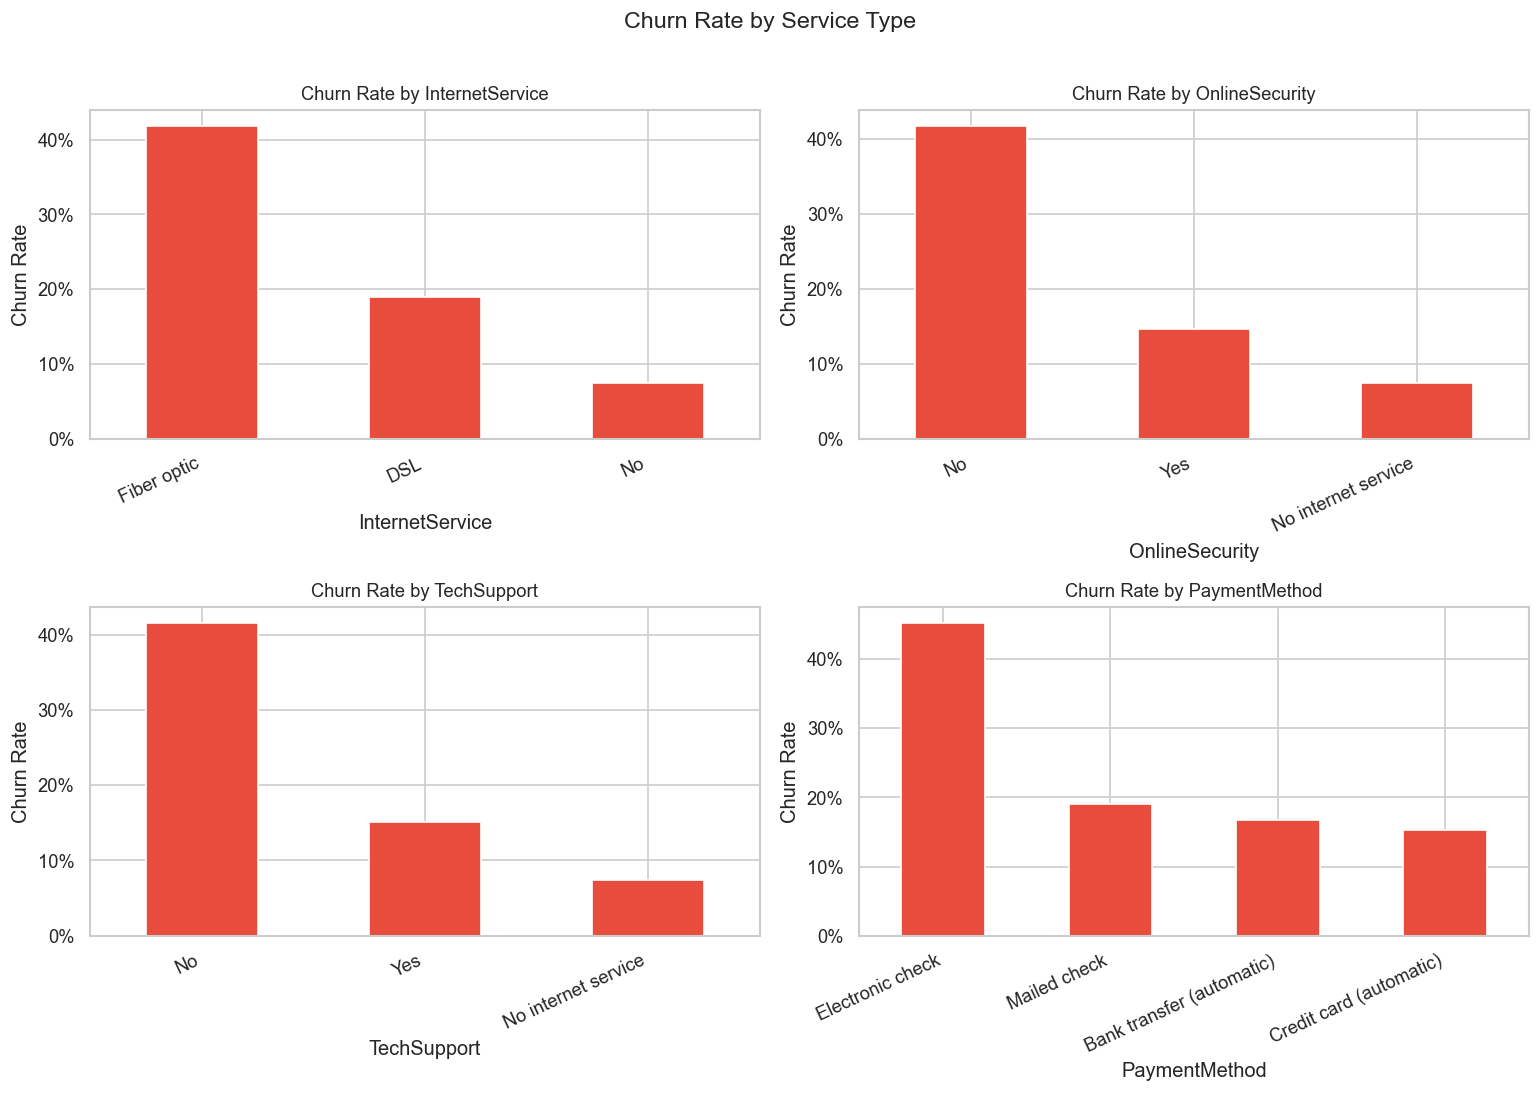

Insights:
- Fiber optic customers churn more than DSL — possibly due to higher pricing
- Customers WITHOUT OnlineSecurity/TechSupport churn significantly more
- Electronic check payers churn most — possibly less committed customers


In [7]:
service_cols = ['InternetService', 'OnlineSecurity', 'TechSupport', 'PaymentMethod']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean())
    churn_rate.sort_values(ascending=False).plot(kind='bar', ax=axes[i], width=0.5, color='#e74c3c')
    axes[i].set_title(f'Churn Rate by {col}', fontsize=11)
    axes[i].set_ylabel('Churn Rate')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=25, ha='right')

plt.suptitle('Churn Rate by Service Type', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Insights:')
print('- Fiber optic customers churn more than DSL — possibly due to higher pricing')
print('- Customers WITHOUT OnlineSecurity/TechSupport churn significantly more')
print('- Electronic check payers churn most — possibly less committed customers')

## 6. Correlation Heatmap (Numeric Features)

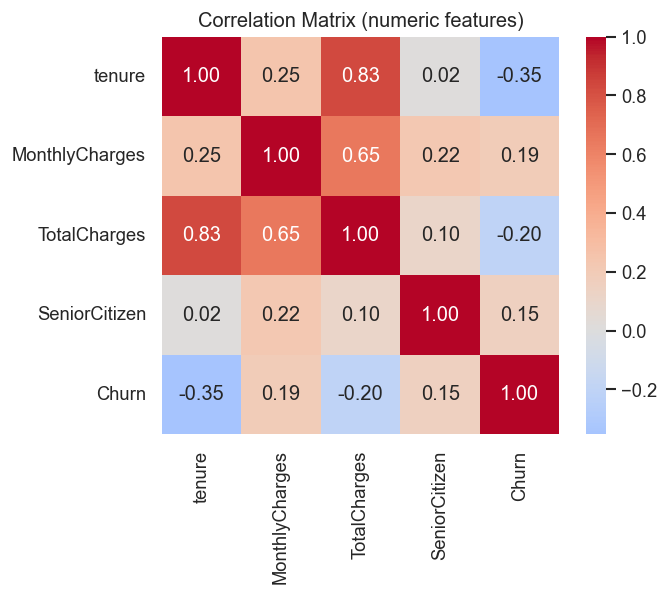

Tenure has the strongest negative correlation with churn (-0.35)
TotalCharges is highly correlated with tenure (0.83) — multicollinearity risk for linear models


In [8]:
df_numeric = df[['tenure','MonthlyCharges','TotalCharges','SeniorCitizen']].copy()
df_numeric['Churn'] = (df['Churn'] == 'Yes').astype(int)

corr = df_numeric.corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation Matrix (numeric features)', fontsize=12)
plt.tight_layout()
plt.show()

print('Tenure has the strongest negative correlation with churn (-0.35)')
print('TotalCharges is highly correlated with tenure (0.83) — multicollinearity risk for linear models')

## 7. Engineered Feature Preview

2026-05-04 14:38:03 | INFO | src.feature_engineering | Feature engineering complete. New features: charges_per_tenure, is_high_value, num_services


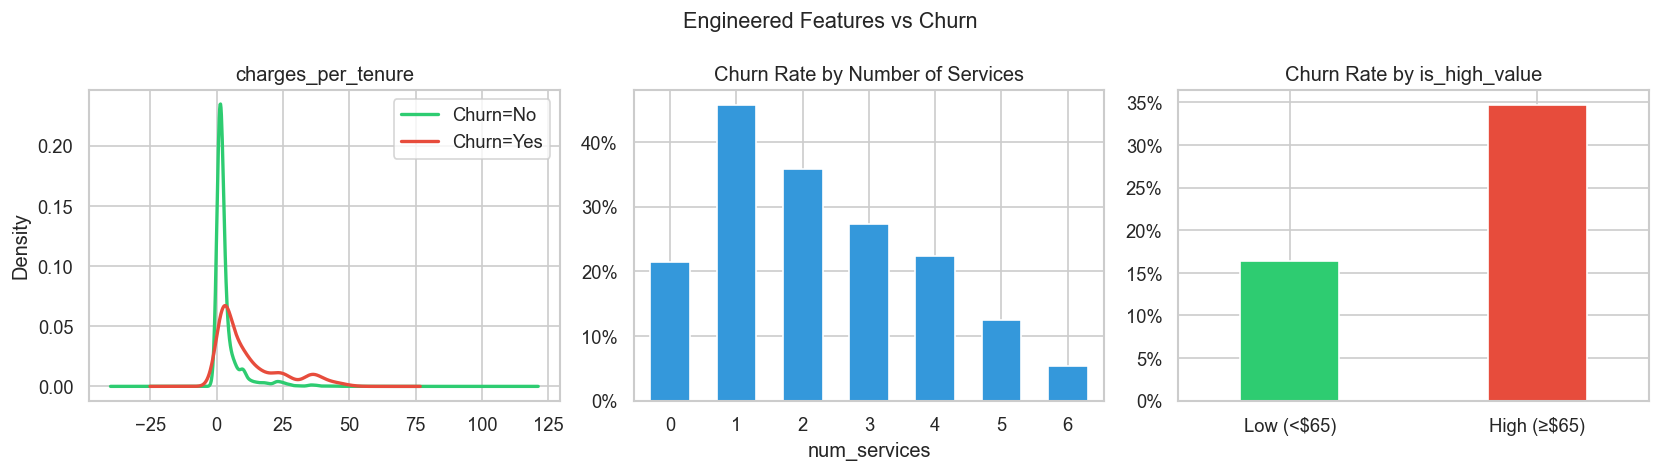

All three engineered features show clear separation between churn/no-churn groups.
→ They should add signal to the model.


In [9]:
import sys, os
sys.path.insert(0, '..')
from src.feature_engineering import add_features

df_fe = add_features(df)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# charges_per_tenure
for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
    df_fe[df_fe['Churn']==label]['charges_per_tenure'].clip(0, 100).plot.kde(
        ax=axes[0], label=f'Churn={label}', color=color, lw=2)
axes[0].set_title('charges_per_tenure')
axes[0].legend()

# num_services
svc_churn = df_fe.groupby('num_services')['Churn'].apply(lambda x: (x=='Yes').mean())
svc_churn.plot(kind='bar', ax=axes[1], color='#3498db', width=0.6)
axes[1].set_title('Churn Rate by Number of Services')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# is_high_value
hv_churn = df_fe.groupby('is_high_value')['Churn'].apply(lambda x: (x=='Yes').mean())
hv_churn.index = ['Low (<$65)', 'High (≥$65)']
hv_churn.plot(kind='bar', ax=axes[2], color=['#2ecc71','#e74c3c'], width=0.4)
axes[2].set_title('Churn Rate by is_high_value')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.suptitle('Engineered Features vs Churn', fontsize=13)
plt.tight_layout()
plt.show()

print('All three engineered features show clear separation between churn/no-churn groups.')
print('→ They should add signal to the model.')

## Key Takeaways for Modeling

| Finding | Implication |
|---|---|
| Month-to-month contracts churn at 43% | Contract type = likely top feature |
| Low tenure → high churn | Tenure is critical; consider non-linear transforms |
| Fiber optic + no security/support → high churn | Add-on services are protective |
| High monthly charges correlate with churn | charges_per_tenure feature is useful |
| ~27% churn rate | Need class_weight='balanced' or SMOTE |
